[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Usernotfoundoops/Adibatic_Quantum_Computing/blob/Different-Implementation/Adiabatic%20Theorem%20Implementation%20(Muti.T)%20%5Bt%20fix%5D.ipynb)

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.integrate import quad
import scipy.integrate as integrate
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter
from scipy.signal import savgol_filter
import scipy.signal

In [55]:
#Scheduling Function Control
def f(t,args):
    T = args['T']
    return t/T #np.sin(np.pi * t / (2 * T))**2 #t/T

In [56]:
# Coupling Parameters
a,b,c,d=0.5,0.7,3,1.5 #large gap
# a,b,c,d=0.5,0.1,0.3,1.5 #medium gap
# a,b,c,d=0.5,0.035,0.3,1.5 #small gap
t=0
T_curr=5000
args={'T':T_curr,'a':a,'b':b,'c':c,'d':d}
args

{'T': 5000, 'a': 0.5, 'b': 0.7, 'c': 3, 'd': 1.5}

In [57]:
#Static and Dynamic Hamiltonian
def H_static(a,b,c):
    data=[[a,b,0],[b,-a,c],[0,c,0]]
    return qt.Qobj(data)

def H_dynamic(d):
    data1=[[-1,0,0],[0,1,0],[0,0,d]]
    return qt.Qobj(data1)

In [58]:
# To check out the Hamiltonian Matrix
def H(t,args): # Time-Dependent Hamiltonian: Adiabatic Evolution
    return H_static(a,b_curr,c) + f(s*T_curr,args) * H_dynamic(d)
H(1,args)

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-0.5  3.   0. ]
 [ 3.   0.5  3. ]
 [ 0.   3.   1.5]]

SINGLE T (Adjust T_curr)

In [8]:
# Variable 'd' Parameter
d_list=np.linspace(0,2,30)[1:] # list of d values, end value = 2

# List of Lists
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

t_list1 = np.linspace(0, T_curr, 200)
T1=t_list1

for l,d_curr in enumerate(d_list):
    args['d'] = d_curr
    listy.append(t_list1)
    eigenvalue,eigenvector=(H_static(a,b,c)).eigenstates()
    psi0=eigenvector[0] # Initial Ground Eigen State for Exact Evolution

    # Total Hamiltonian: Exact Evolution
    H_total=[H_static(a,b,c),[H_dynamic(d_curr),f]]
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    # List
    transition_probability=[]
    ground_temp,first_temp,second_temp=[],[],[]
    adiabatic_error_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i, t in enumerate(t_list1):

        s = t / T_curr  # scaled time, s ∈ [0, 1]

        def H_at_s(s,args): # Time-Dependent Hamiltonian: Adiabatic Evolution
            return H_static(a,b,c) + f(s*T_curr,args) * H_dynamic(d_curr)

        # First,Second, and Third Eigen Levels
        evals, estates = H_at_s(s,args).eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])

        # Transition Probability: |<Psi_adiabatic_ground_state|Psi_exact_ground_state>|^2
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        transition_probability.append(1 - fidelity)

       # Exact Adiabatic Error: ||P_tau(s) - P(s)||
        P_instantaneous=estates[0]*estates[0].dag() #outer product
        P_exact=final.states[i].proj() #outer product
        vector_distance=(P_instantaneous-P_exact).norm()
        adiabatic_error_temp.append(vector_distance)

        m = 1 # No. of Eigenstates Inside Projector Subspace

        # dH/ds = H_dynamic (exact, since H(s) = H_static + s * H_dynamic)
        def dH_ds():
            return np.linalg.norm(H_dynamic(d_curr).full(), ord=2)

        def bandgap_func(s): # Bandgap Function
            evals, _ = H_at_s(s,args).eigenstates()
            return float(evals[1] - evals[0])

        # d²H/ds² = 0 for linear interpolation, so the Ḧ term vanishes
        # Integrand: 7m√m * ||dH/ds||² / g(s')³
        def integrand(s):
            g = bandgap_func(s)
            return (dH_ds()**2) / g**3

        dH_dot_norm = dH_ds()
        g0 = bandgap_func(0)
        gs = bandgap_func(s)

        # Boundary term (|u.b. means evaluated at 0 and s)
        ub_boundary = (m * dH_dot_norm /T_curr) * (1/g0**2 + 1/gs**2)

        # Integral term: integrate over s', from 0 to s
        ub_integral, _ = quad(integrand, 0, s)
        ub_integral *= (7 * m * np.sqrt(m)) / T_curr

        total_equation = ub_boundary + ub_integral
        error_temp.append(total_equation)

    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    adiabatic_error_full.append(adiabatic_error_temp)
    transition_probability_full.append(transition_probability)
    error_full_list.append(error_temp)

In [13]:
# Variable 'b' Parameter
b_list=np.linspace(0,3,30)[1:] # list of d values, end value = 3

# List of Lists
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

t_list1 = np.linspace(0, T_curr, 200)
T1=t_list1


for b_curr in b_list:

    args['b'] = b_curr
    eigenvalue,eigenvector=(H_static(a,b_curr,c)).eigenstates()
    psi0=eigenvector[0] # Initial Ground Eigen State for Exact Evolution
    listy.append(t_list1)

    # Total Hamiltonian: Exact Evolution
    H_total=[H_static(a,b_curr,c),[H_dynamic(d),f]]
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    # List
    transition_probability=[]
    ground_temp,first_temp,second_temp=[],[],[]
    adiabatic_error_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i, t in enumerate(t_list1):
        args['T'] = T_curr
        s = t / T_curr  # scaled time, s ∈ [0, 1]

        def H_at_s(s,args): # Time-Dependent Hamiltonian: Adiabatic Evolution
            return H_static(a,b_curr,c) + f(s*T_curr,args) * H_dynamic(d)

        # First,Second, and Third Eigen Levels
        evals, estates = H_at_s(s,args).eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])

        # Transition Probability: |<Psi_adiabatic_ground_state|Psi_exact_ground_state>|^2
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        transition_probability.append(1 - fidelity)

        # Exact Adiabatic Error: ||P_tau(s) - P(s)||
        P_instantaneous=estates[0]*estates[0].dag() #outer product
        P_exact=final.states[i].proj() #outer product
        vector_distance=(P_instantaneous-P_exact).norm()
        # vector_distance = np.sqrt(2 * (1 - np.abs(estates[0].overlap(final.states[i]))))
        adiabatic_error_temp.append(vector_distance)

        m = 1 # No. of Eigenstates Inside Projector Subspace

        # dH/ds = H_dynamic (exact, since H(s) = H_static + s * H_dynamic)
        def dH_ds():
            return np.linalg.norm(H_dynamic(d).full(), ord=2)

        def bandgap_func(s): # Bandgap Function
            evals, _ = H_at_s(s,args).eigenstates()
            return float(evals[1] - evals[0])

        # d²H/ds² = 0 for linear interpolation, so the Ḧ term vanishes
        # Integrand: 7m√m * ||dH/ds||² / g(s')³
        def integrand(s):
            g = bandgap_func(s)
            return (dH_ds()**2) / g**3

        dH_dot_norm = dH_ds()
        g0 = bandgap_func(0)
        gs = bandgap_func(s)

        # Boundary term (|u.b. means evaluated at 0 and s)
        ub_boundary = (m * dH_dot_norm /T_curr) * (1/g0**2 + 1/gs**2)

        # Integral term: integrate over s', from 0 to s
        ub_integral, _ = quad(integrand, 0, s)
        ub_integral *= (7 * m * np.sqrt(m)) / T_curr

        total_equation = ub_boundary + ub_integral
        error_temp.append(total_equation)

    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    adiabatic_error_full.append(adiabatic_error_temp)
    transition_probability_full.append(transition_probability)
    error_full_list.append(error_temp)

In [45]:
# Constant d parameter

# List of Lists
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

# List
transition_probability=[]
ground_temp,first_temp,second_temp=[],[],[]
adiabatic_error_temp,errors_fidelity_temp=[],[]
error_temp=[]

t_list1 = np.linspace(0, T_curr, 100)
T1=t_list1

eigenvalue,eigenvector=(H_static(a,b,c)).eigenstates()
psi0=eigenvector[0] # Initial Ground Eigen State for Exact Evolution

listy.append(t_list1)

# Total Hamiltonian: Exact Evolution
H_total=[H_static(a,b,c),[H_dynamic(d),f]]
final = qt.sesolve(H_total, psi0, t_list1, args=args)

for i, t in enumerate(t_list1):
    s = t / T_curr  # scaled time, s ∈ [0, 1]

    def H_at_s(s,args): # Time-Dependent Hamiltonian: Adiabatic Evolution
        return H_static(a,b,c) + f(s*T_curr,args) * H_dynamic(d)

     # First,Second, and Third Eigen Levels
    evals, estates = H_at_s(s,args).eigenstates()
    ground_temp.append(evals[0])
    first_temp.append(evals[1])
    second_temp.append(evals[2])

    # Transition Probability: |<Psi_adiabatic_ground_state|Psi_exact_ground_state>|^2
    fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
    transition_probability.append(1 - fidelity)

    # Exact Adiabatic Error: ||P_tau(s) - P(s)||
    P_instantaneous=estates[0]*estates[0].dag() #outer product
    P_exact=final.states[i].proj() #outer product
    vector_distance=(P_instantaneous-P_exact).norm()
    adiabatic_error_temp.append(vector_distance)

    m = 1 # No. of Eigenstates Inside Projector Subspace

    # dH/ds = H_dynamic (exact, since H(s) = H_static + s * H_dynamic)
    def dH_ds():
        return np.linalg.norm(H_dynamic(d).full(), ord=2)

    def bandgap_func(s): # Bandgap Function
        evals, _ = H_at_s(s,args).eigenstates()
        return float(evals[1] - evals[0])

    # d²H/ds² = 0 for linear interpolation, so the Ḧ term vanishes
    # Integrand: 7m√m * ||dH/ds||² / g(s')³
    def integrand(s):
        g = bandgap_func(s)
        return (dH_ds()**2) / g**3

    dH_dot_norm = dH_ds()
    g0 = bandgap_func(0)
    gs = bandgap_func(s)

    # Boundary term (|u.b. means evaluated at 0 and s)
    ub_boundary = (m * dH_dot_norm /T_curr) * (1/g0**2 + 1/gs**2)

    # Integral term: integrate over s', from 0 to s
    ub_integral, _ = quad(integrand, 0, s)
    ub_integral *= (7 * m * np.sqrt(m)) / T_curr

    total_equation = ub_boundary + ub_integral
    error_temp.append(total_equation)

ground_full_T.append(ground_temp)
first_full_T.append(first_temp)
second_full_T.append(second_temp)
adiabatic_error_full.append(adiabatic_error_temp)
transition_probability_full.append(transition_probability)
error_full_list.append(error_temp)

In [53]:
#Hamiltonian Matrix
print(args)
H_at_s(1,args) #t=1

{'T': 5000, 'a': 0.5, 'b': 0.7, 'c': 3, 'd': 1.5}


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-0.5  0.7  0. ]
 [ 0.7  0.5  3. ]
 [ 0.   3.   1.5]]

Multiple T

In [35]:
T1=np.linspace(100,5000,50) # T=5000
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

for T_curr in T1:
    args['T'] = T_curr

    eigenvalue,eigenvector=H_static(a,b,c).eigenstates()
    psi0=eigenvector[0] # Initial Ground Eigen State for Exact Evolution

    dt = 100  # fixed spacing
    # n_points = max(100, int(T_curr / dt))
    t_list1 = np.linspace(0, T_curr, dt) # use n_points for varying list size (Warning: Increases Computation Time)
    listy.append(t_list1)

    # Total Hamiltonian: Exact Evolution
    H_total=[H_static(a,b,c),[H_dynamic(d),f]]
    final = qt.sesolve(H_total, psi0, t_list1, args=args)

    # List
    transition_probability=[]
    ground_temp,first_temp,second_temp=[],[],[]
    adiabatic_error_temp,errors_fidelity_temp=[],[]
    error_temp=[]

    for i, t in enumerate(t_list1):
        s = t / T_curr  # scaled time, s ∈ [0, 1]

        def H_at_s(s,args):     # Time-Dependent Hamiltonian: Adiabatic Evolution
            return H_static(a,b,c) + f(s*T_curr,args) * H_dynamic(d)

        def bandgap_func(s):    # Bandgap Function
            evals, _ = H_at_s(s,args).eigenstates()
            return float(evals[1] - evals[0])

        # First, Second, and Third Eigen Levels
        evals, estates = H_at_s(s,args).eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])

        # Transition Probability: |<Psi_adiabatic_ground_state|Psi_exact_ground_state>|^2
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        transition_probability.append(1 - fidelity)

        # Exact Adiabatic Error: ||P_tau(s) - P(s)||
        P_instantaneous=estates[0]*estates[0].dag() #outer product
        P_exact=final.states[i].proj() #outer product
        vector_distance=(P_instantaneous-P_exact).norm()

        # Different implementation_1 of ||P_tau(s) - P(s)||
        # overlap = estates[0].overlap(final.states[i])
        # phase = overlap / np.abs(overlap)  # e^{iφ}
        # diff_vector = final.states[i] - phase * estates[0]
        # vector_distance = np.linalg.norm(diff_vector.full(), ord=2)

        # Different implementation_2 of ||P_tau(s) - P(s)||
        # psi_t = final.states[i]        # time-evolved state
        # e0 = estates[0]                # instantaneous ground state
        # P_tau = psi_t * psi_t.dag()   # outer product
        # P_s   = e0 * e0.dag()         # outer product
        # diff_projector = P_tau - P_s
        # vector_distance = diff_projector.norm()  # operator norm
        # adiabatic_error_temp.append(vector_distance)

        # Different implementation_3 of ||P_tau(s) - P(s)||
        # overlapy = abs(estates[0].overlap(final.states[i]))**2
        # vector_distance = np.sqrt(max(0.0, 2 - 2*np.sqrt(overlapy)))

        adiabatic_error_temp.append(vector_distance)

        m = 1 # No. of Eigenstates Inside Projector Subspace

        # dH/ds = H_dynamic (exact, since H(s) = H_static + s * H_dynamic)
        def dH_ds():
            return np.linalg.norm(H_dynamic(d).full(), ord=2)

        # d²H/ds² = 0 for linear interpolation, so the Ḧ term vanishes
        # Integrand: 7m√m * ||dH/ds||² / g(s')³
        def integrand(s):
            g = bandgap_func(s)
            return (dH_ds()**2) / g**3

        dH_dot_norm = dH_ds()
        g0 = bandgap_func(0)
        gs = bandgap_func(s)

        # Boundary term (|u.b. means evaluated at 0 and s)
        ub_boundary = (m * dH_dot_norm /T_curr) * (1/g0**2 + 1/gs**2)

        # Integral term: integrate over s', from 0 to s
        ub_integral, _ = integrate.quad(integrand, 0, s)
        ub_integral *= (7 * m * np.sqrt(m)) / T_curr

        total_equation = ub_boundary + ub_integral
        error_temp.append(total_equation)

    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    adiabatic_error_full.append(adiabatic_error_temp)
    transition_probability_full.append(transition_probability)
    error_full_list.append(error_temp)

VERIFICATION OF d or b PARAMETER WITH EXACT VALUE (FOR TESTING PURPOSE)

In [ ]:
# First Run Variable d or b Parameter Cell Before Running This Cell
storage=[end_error_per_T,errorbound_per_T,d_list] # replace with b_list or d_list appropriately
# storage

In [ ]:
# Second Run Constant d or b Value Cell Then This Cell to Compare
AE=[i for i in storage[0]]
UB=[i for i in storage[1]]
d_li=[i for i in storage[2]]

pick=14

print(AE[pick],UB[pick],d_li[pick]) #variable d or b
print(adiabatic_error_full[-1][-1],error_full_list[-1][-1],d) #constant d or b

GRAPHICAL PLOTS

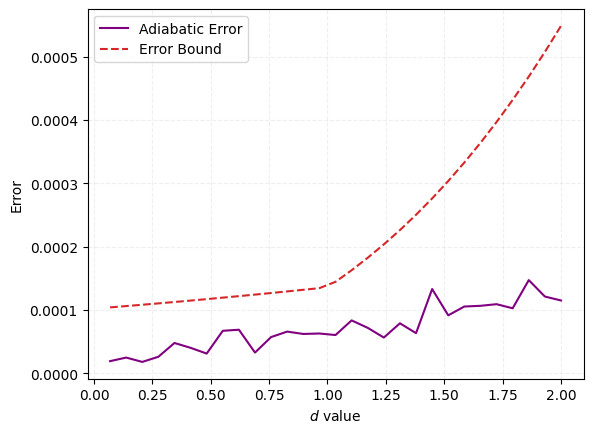

In [9]:
# Variable d Parameter vs Error Metrics

end_error_per_T = [errors[-1] for errors in adiabatic_error_full]
errorbound_per_T = [errors[-1] for errors in error_full_list]

plt.figure()
plt.plot(d_list,end_error_per_T,'-',color='purple',label='Adiabatic Error')
plt.plot(d_list,errorbound_per_T,'--',color='tab:red',label='Error Bound')
plt.grid(True, ls="--",alpha=0.2)
plt.xlabel('$d$ value')
plt.ylabel('Error')
# plt.title(f'Error vs $d$ variable ($T={round(T1[k])}$)')
plt.legend()
# plt.savefig(f'/home/user_location/Error vs d variable (a,b,c={a,b,c}).png') #save_directory

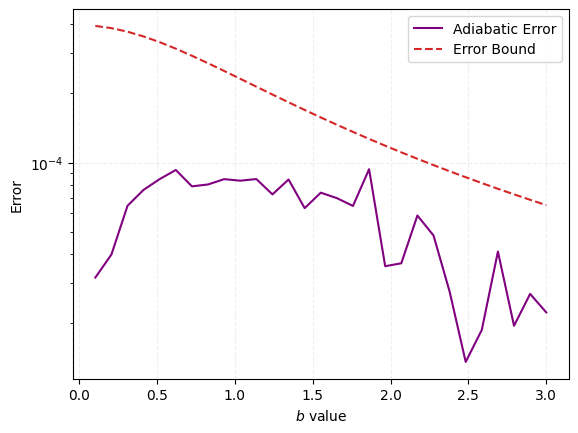

In [14]:
# Variable b Parameter vs Error Metrics
end_error_per_T = [errors[-1] for errors in adiabatic_error_full]
errorbound_per_T = [errors[-1] for errors in error_full_list]

plt.figure()
plt.semilogy(b_list,end_error_per_T,'-',color='purple',label='Adiabatic Error')
plt.semilogy(b_list,errorbound_per_T,'--',color='tab:red',label='Error Bound')
plt.grid(True, ls="--",alpha=0.2)
plt.xlabel('$b$ value')
plt.ylabel('Error')
# plt.title(f'Error vs $b$ variable ($T={round(T1[k])}$)')
plt.legend()
# plt.savefig(f'/home/user_location/Error vs b variable (a,c,d={a,c,d}).png')

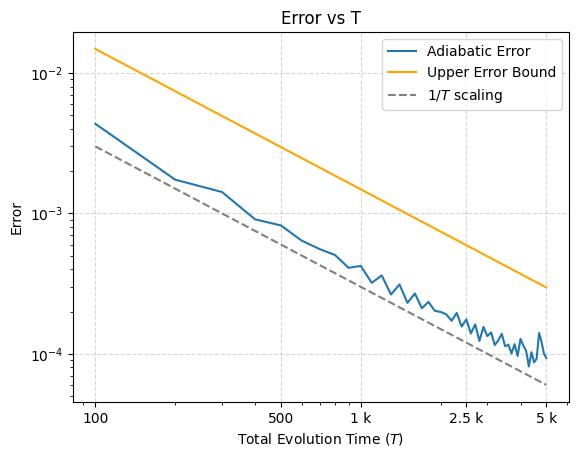

In [99]:
# Total Evolution Time T vs Error Metrics

# max_errors_per_T = [max(errors) for errors in transition_probability_full] #Use 3,4 line to plot max values
# max_errorbound_per_T = [max(errors) for errors in error_full_list]
end_error_per_T = [errors[-1] for errors in adiabatic_error_full]
errorbound_per_T = [errors[-1] for errors in error_full_list]

plt.figure()
# plt.loglog(T1, max_errors_per_T,'-',color='darkviolet')
# plt.loglog(T1, max_errorbound_per_T,'-',color='orange')
smoothened_end_error_per_T = savgol_filter(end_error_per_T, window_length=5,polyorder=0)
plt.loglog(T1, end_error_per_T,'-',color='tab:blue',alpha=1,zorder=10,label='Adiabatic Error')
plt.loglog(T1, errorbound_per_T,'-',color='orange',label='Upper Error Bound')
# plt.loglog(T1, smoothened_end_error_per_T,'-',color='red',alpha=0.9,label='Smoothened Adiabatic Error')
plt.loglog(T1, 0.3/T1, '--', label='$1/T$ scaling', color='gray')
# plt.xticks([100, 500, 1000, 2500, 5000,10000], ['100', '500', '1k', '2.5k', '5k','10k'])
plt.xticks([100, 500, 1000, 2500, 5000], ['100', '500', '1 k', '2.5 k', '5 k'])
plt.grid(True, ls="--", alpha=0.5)
plt.title('Error vs T')
plt.xlabel(f'Total Evolution Time $(T)$')
plt.ylabel(f'Error')
plt.legend()
# plt.savefig(r'/home/user_location/Error vs End T.png') # Save Img

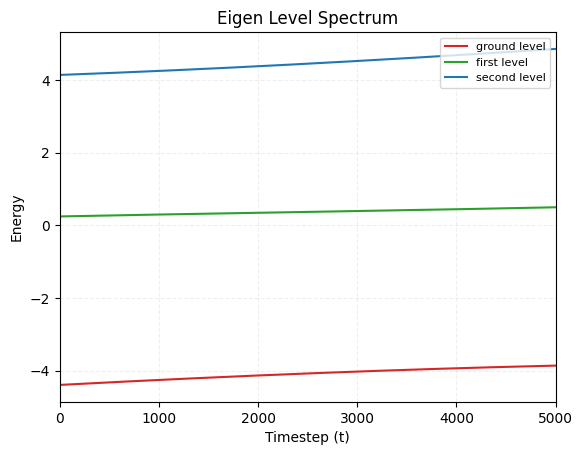

In [15]:
# Eigen Levels E vs Time t

plt.figure()
plt.plot(listy[-1], ground_temp, color='tab:red', linestyle='-', label='ground level')
plt.plot(listy[-1],first_temp , color='tab:green', linestyle='-', label='first level')
plt.plot(listy[-1], second_temp, color='tab:blue', linestyle='-', label='second level')
plt.title('Eigen Level Spectrum')
plt.xlabel('Timestep (t)')
plt.ylabel('Energy')
plt.legend(fontsize=8)
plt.autoscale(enable=True, axis='x', tight=True)
plt.grid(linestyle='--',alpha=0.2)
# plt.savefig(f'/home/user_location/EL(a,b,c,d={a,b,c,d}).png')


At T =  5000.0


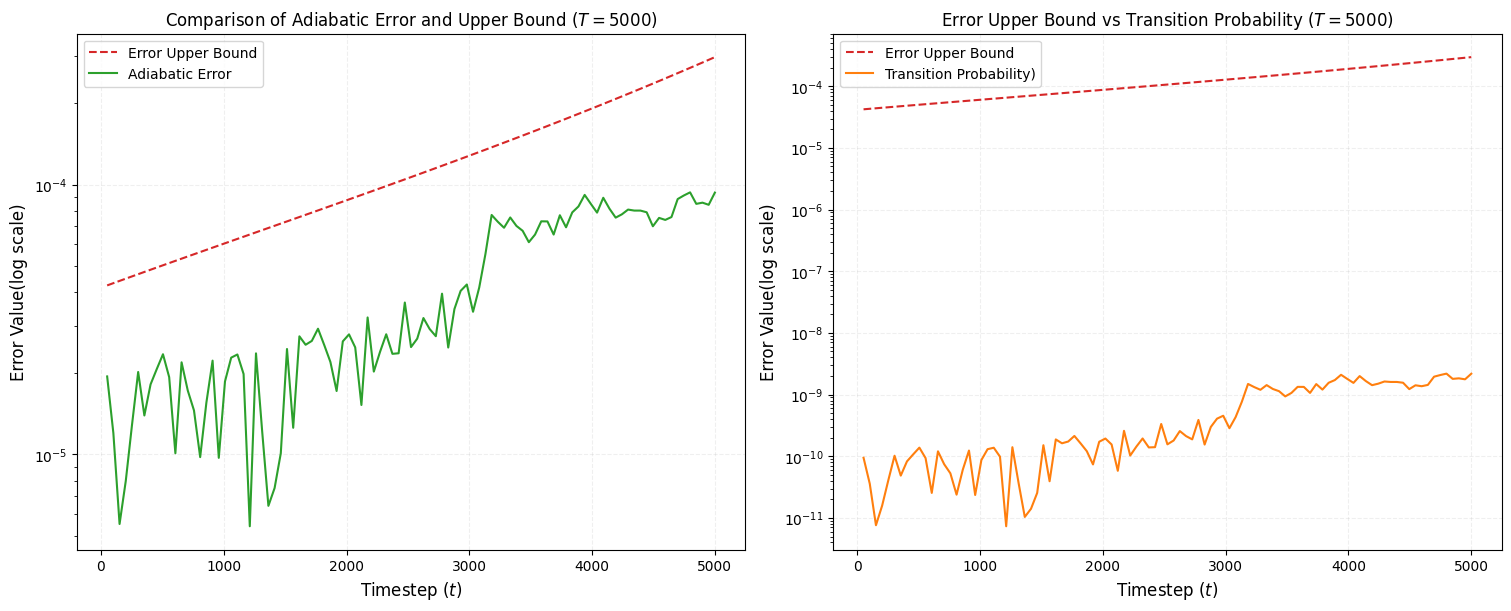

In [36]:
# Error Metrics and Transition Probability vs Time t

k=-1 # for (Multiple T) adjust k=1,9,19,39,-1; (Single T) k=-1 only.
print('At T = ',T1[k]) # To check T value

fig, ax = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')

# --- LEFT GRAPH (ax[0]) ---
ax[0].plot(listy[k][1:], error_full_list[k][1:],'--', color='tab:red', label='Error Upper Bound')
ax[0].plot(listy[k][1:], adiabatic_error_full[k][1:],  color='tab:green', label='Adiabatic Error')
ax[0].set_ylabel('Error Value(log scale)', fontsize=12)
ax[0].set_xlabel('Timestep ($t$)', fontsize=12)
ax[0].set_yscale('log')
ax[0].legend()
ax[0].set_title(f'Comparison of Adiabatic Error and Upper Bound ($T={round(T1[k])}$)')
ax[0].grid(linestyle='--', alpha=0.2)

# --- RIGHT GRAPH (ax[1]) ---
ax[1].plot(listy[k][1:], error_full_list[k][1:], '--',color='tab:red',label='Error Upper Bound ')
ax[1].plot(listy[k][1:], transition_probability_full[k][1:], color='tab:orange', label='Transition Probability)')
ax[1].set_ylabel('Error Value(log scale)', fontsize=12)
ax[1].set_xlabel('Timestep ($t$)', fontsize=12)
ax[1].set_yscale('log')
ax[1].legend()
ax[1].set_title(f'Error Upper Bound vs Transition Probability ($T={round(T1[k])}$)')
ax[1].grid(linestyle='--', alpha=0.2)
# plt.savefig(f'/home/user_location/AE and TP vs t(T={T1[k]}).png') # Save Image
# print(adiabatic_error_full[-1])

At T =  5000.0


Text(70.10942559136284, 0.5, 'Error Magnitude (log scale)')

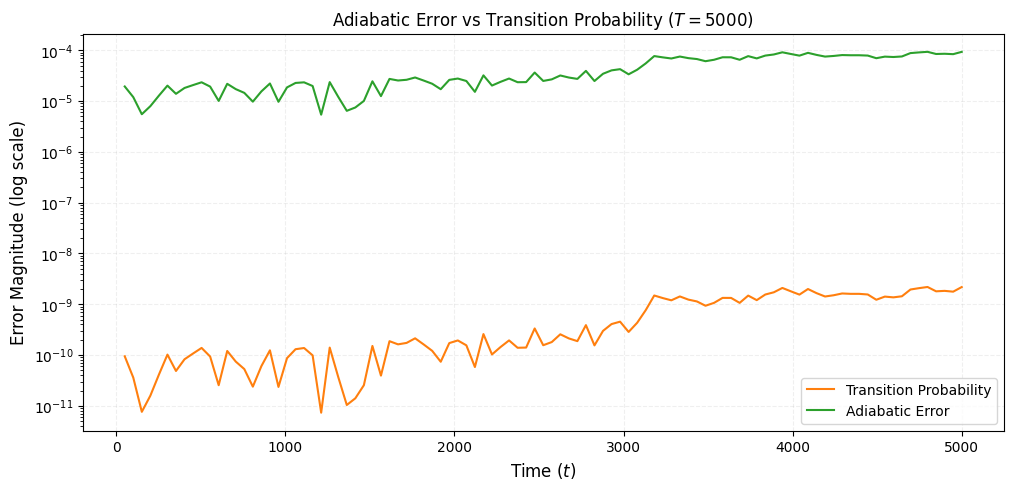

In [39]:
# Comparison of Error Metrics vs Transition Probability
print('At T = ', T1[k])
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(listy[k][1:], transition_probability_full[k][1:], color='tab:orange', label='Transition Probability')
ax1.plot(listy[k][1:], adiabatic_error_full[k][1:], color='tab:green', label='Adiabatic Error')
ax1.set_yscale('log') # Both metrics are best viewed on a log scale
ax1.grid(True, which="major", ls="--", alpha=0.2)
ax1.set_title(f'Adiabatic Error vs Transition Probability ($T={round(T1[k])}$)')
ax1.legend()
fig.tight_layout(rect=[0, 0, 1, 0.95])
ax1.set_xlabel('Time ($t$)', fontsize=12)
ax1.set_ylabel('Error Magnitude (log scale)', fontsize=12)

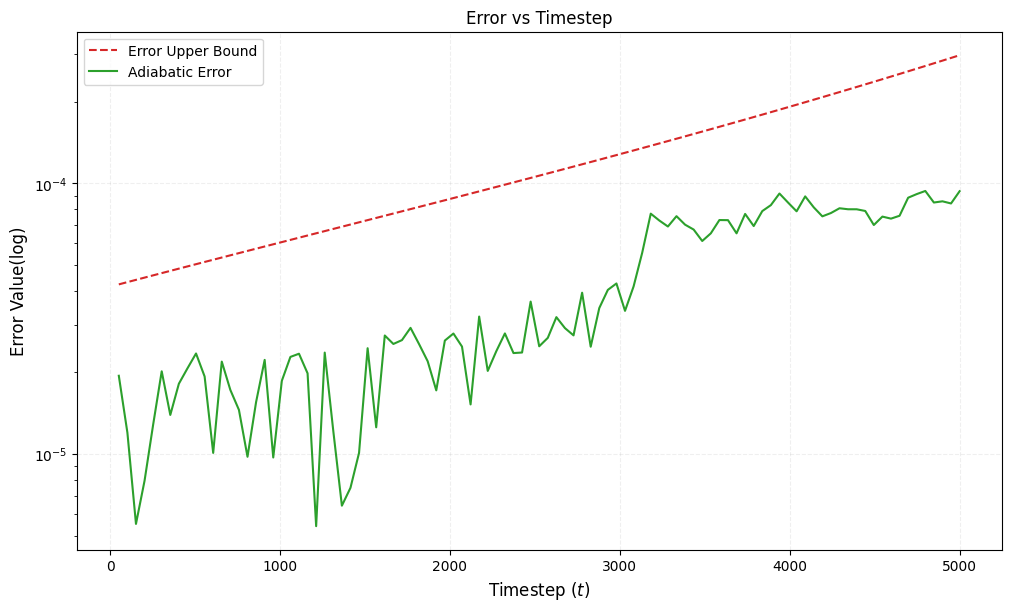

In [38]:
# Individual Plot of Adiabatic Error and Error Upper Bound vs Time

fig, ax = plt.subplots(figsize=(10, 6),layout='constrained')
Approximate_Error= ax.plot(listy[k][1:], error_full_list[k][1:],'--', color='tab:red',label='Error Upper Bound')
Ideal_Error=ax.plot(listy[k][1:],  adiabatic_error_full[k][1:], color='tab:green',label='Adiabatic Error')
ax.set_ylabel('Error Value(log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_yscale('log')
ax.legend()
ax.set_title('Error vs Timestep')
plt.grid(linestyle='--',alpha=0.2)

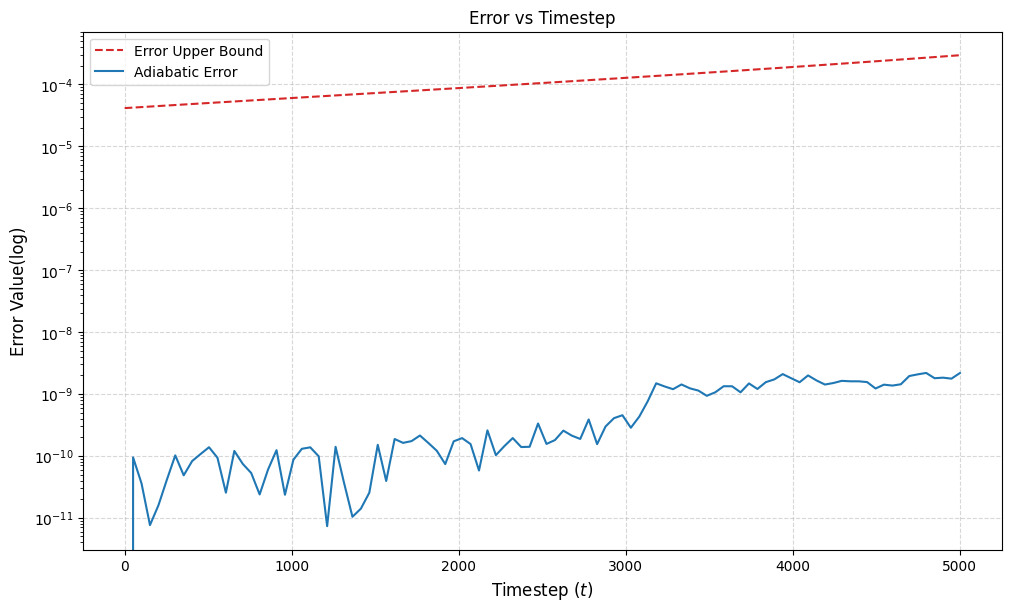

In [26]:
# Individual Plot of Transition Probability and Error Upper Bound vs Time

fig, ax = plt.subplots(figsize=(10, 6),layout='constrained')
Approximate_Error= ax.plot(listy[k], error_full_list[k],'--', color='tab:red',label='Error Upper Bound')
Ideal_Error=ax.plot(listy[k], transition_probability_full[k],'-', color='tab:blue',label='Adiabatic Error')
ax.set_ylabel('Error Value(log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_yscale('log')
ax.legend()
ax.set_title('Error vs Timestep')
plt.grid(linestyle='--',alpha=0.5)

ANIMATION

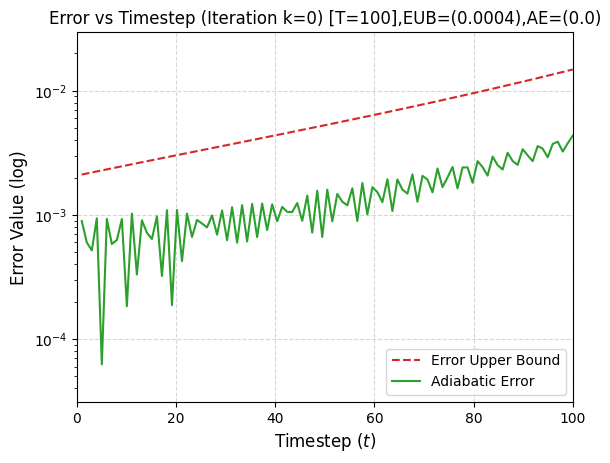

In [40]:
# Error Metrics vs Time

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_ylabel('Error Value (log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_title('Error vs Timestep Animation')
plt.grid(linestyle='--', alpha=0.5)
line_approx, = ax.plot([], [], '--', color='tab:red', label=f'Error Upper Bound')#({round(errorbound_per_T[k], 4)})
line_ideal, = ax.plot([], [], color='tab:green', label=f'Adiabatic Error')# ({round(end_error_per_T[k], 4)})


def update(k):

    # line_tp, = ax.plot([], [], color='tab:orange', label='Transition Probability')
    ax.legend(loc='lower right')
    ax.set_ylim((min(sorted(list(adiabatic_error_full[k]))[1],sorted(list(error_full_list[k]))[0])*(1-1/2)), (max(error_full_list[k][1:])*(1+1))) #here max() should have the highest value(adiabatic error or ideal error).
    # ax.set_ylim((min(transition_probability_full[k][1:])*(1-1/2)), (max(error_full_list[k][1:])*(1+1)))
    ax.set_xlim(min(listy[0]), max(listy[k]))
    x_data = listy[k][1:]
    y_approx = error_full_list[k][1:]
    y_ideal = adiabatic_error_full[k][1:]
    # y_tp = transition_probability_full[k][1:]
    line_approx.set_data(x_data, y_approx)
    line_ideal.set_data(x_data, y_ideal)
    # line_tp.set_data(x_data, y_tp)
    ax.set_title(f'Error vs Timestep (Iteration k={k}) [T={round(T1[k])}],EUB=({round(errorbound_per_T[k], 4)}),AE=({round(end_error_per_T[k], 4)})')
    return line_approx, line_ideal, #line_tp

fps = 5 #earlier, it was 10. interval unit is in ms.
ani = FuncAnimation(fig, update, frames=len(error_full_list),interval=1000/fps, blit=True)
# ani.save(r'/home/user_location/error_animation.gif', writer=PillowWriter(fps=fps)) # Save Folder
plt.show()

REDUNDANT CODE (DO NOT USE)

In [ ]:
fig, ax = plt.subplots(figsize=(10,6),layout='constrained')
ax.set_yscale('log')
ax.set_ylabel('Error Value (log)', fontsize=12)
ax.set_xlabel('Timestep ($t$)', fontsize=12)
ax.set_title('Error vs Timestep Animation')
plt.grid(linestyle='--', alpha=0.5)

line_approx, = ax.plot([], [], '--', color='tab:red', label='Error Upper Bound')
line_tp, = ax.plot([], [], color='tab:orange', label='Transition Probability')
ax.legend()
ax.set_xlim(min(listy[0]), max(listy[-1]))
# ax.set_ylim(1e-8, 5)

def update(k):
    ax.set_ylim((min(transition_probability_full[k][1:])*(1-1/2)), (max(error_full_list[k][1:])*(1+1)))
    ax.set_xlim(min(listy[0]), max(listy[k]))
    x_data = listy[k][1:]
    y_approx = error_full_list[k][1:]
    y_ideal = transition_probability_full[k][1:]
    line_approx.set_data(x_data, y_approx)
    line_tp.set_data(x_data, y_ideal)
    ax.set_title(f'Error vs Timestep (Iteration k={k} [T={round(T1[k])}])')

    return line_approx, line_ideal

ani = FuncAnimation(fig, update, frames=len(error_full_list),
                    interval=100, blit=True)

# ani.save(r'/home/user_location/error_animation1_updated_new.gif', writer='pillow')
plt.show()

In [ ]:
#single T backup
TT=1000
T1=np.linspace(TT,TT,1)
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

for T_curr in T1:
    args['T'] = T_curr
    t_list1 = np.linspace(0, T_curr, 200)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    transition_probability=[]
    ground_temp,first_temp,second_temp=[],[],[]
    adiabatic_error_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i,t in enumerate(t_list1):
        # s=t/T_curr

        # f_val = f(t, args)

        def f_val(t):
            return f(t, args)
        def H_t(t):#instantaneous_Hamiltonian
            return H_static + f_val(t) * H_dynamic(d)
        evals, estates = H_t(t).eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])

        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        transition_probability.append(1 - fidelity)

        #Norm
        diff_vector = final.states[i] - estates[0]
        vector_distance = np.linalg.norm(diff_vector.full(),ord=2)
        adiabatic_error_temp.append(vector_distance)

        # Upper Bound for ERROR
        m = 1
        def dH_1_norm(b):
            dH_1 = (H_dynamic(d)/T_curr).full()
            return np.linalg.norm(dH_1,ord=2)

        def bandgap_func(t):
            eigenvalue1,eigenvector1=H_t(t).eigenstates()
            gg=eigenvalue1[1]-eigenvalue1[0]
            return gg.item()

        def dH_1_norm_squared(t):
            dH_11=dH_1_norm(b)
            g1=bandgap_func(t)
            return dH_11**2/g1**3

        ub_1 = m * dH_1_norm(b) * ((1 / bandgap_func(0) ** 2)+(1/bandgap_func(t) ** 2))
        ub_4 = integrate.quad(dH_1_norm_squared, 0, t)
        total_equation = ub_1  + (ub_4[0] * 7 * m * np.sqrt(m))
        error_temp.append(total_equation)

    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    adiabatic_error_full.append(adiabatic_error_temp)
    transition_probability_full.append(transition_probability)
    error_full_list.append(error_temp)


In [ ]:
#multi T backup
T1=np.linspace(100,5000,100)
listy=[]
ground_full_T, first_full_T, second_full_T=[],[],[]
transition_probability_full,error_full_list=[],[]
adiabatic_error_full=[]

for T_curr in T1:
    args['T'] = T_curr
    t_list1 = np.linspace(0, T_curr, 200)
    listy.append(t_list1)
    final = qt.sesolve(H_total, psi0, t_list1, args=args)
    transition_probability=[]
    ground_temp,first_temp,second_temp=[],[],[]
    adiabatic_error_temp,errors_fidelity_temp=[],[]
    error_temp=[]
    for i,t in enumerate(t_list1):
        f_val = f(t, args)
        H_t = H_static + f_val * H_dynamic(b)
        evals, estates = H_t.eigenstates()
        ground_temp.append(evals[0])
        first_temp.append(evals[1])
        second_temp.append(evals[2])
        fidelity = np.abs(estates[0].overlap(final.states[i])) ** 2
        transition_probability.append(1 - fidelity)

        #Norm
        diff_vector = estates[0] - final.states[i]
        diff_vector_converted = diff_vector.full()
        vector_distance = np.linalg.norm(diff_vector_converted,ord=2)
        adiabatic_error_temp.append(vector_distance)

        # Upper Bound for ERROR
        m = 1
        def dH_1_norm(b):
            dH_1 = (H_dynamic(b)/T_curr).full()
            return np.linalg.norm(dH_1,ord=2)
        def dH_1_norm_squared(t):
            dH_11=dH_1_norm(b)
            f_value=f(t, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            g1=eigenvalue1[1]-eigenvalue1[0]
            gg=dH_11**2/g1**3
            return gg
        def bandgap_func(t):
            f_value=f(T_curr, args)
            H_tt = H_static + f_value * H_dynamic(b)
            eigenvalue1,eigenvector1=H_tt.eigenstates()
            gg=eigenvalue1[1]-eigenvalue1[0]
            return gg.item()

        ub_1 = m * dH_1_norm(b) * ((1 / bandgap_func(0) ** 2)+(1/bandgap_func(T_curr) ** 2))
        ub_4 = integrate.quad(dH_1_norm_squared, 0, t)
        total_equation = ub_1  + (ub_4[0] * 7 * m * np.sqrt(m))
        error_temp.append(total_equation)


    ground_full_T.append(ground_temp)
    first_full_T.append(first_temp)
    second_full_T.append(second_temp)
    adiabatic_error_full.append(adiabatic_error_temp)
    transition_probability_full.append(transition_probability)
    error_full_list.append(error_temp)